# Projet Data Mining — Prédiction du Défaut de Remboursement de Prêt

## Objectif
Ce projet réalise une analyse exploratoire complète du jeu de données **Loan Default** en appliquant des techniques de stat:

**Variable cible** : `Status` — 0 = pas de défaut, 1 = défaut de remboursement

---
# 0. Importation des librairies et des données

In [1]:
from warnings import filterwarnings
filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.style.use('ggplot')
sns.set_palette('Set2')

In [2]:
df_full = pd.read_csv('Loan_Default.csv')

# Sélection des variables les plus pertinentes
quantitative = ['loan_amount', 'income', 'Credit_Score', 'rate_of_interest',
                'term', 'LTV', 'dtir1', 'property_value']
qualitative  = ['Gender', 'loan_type', 'loan_purpose', 'age',
                'Region', 'credit_type', 'approv_in_adv', 'Credit_Worthiness']
target = 'Status'

df = df_full[quantitative + qualitative + [target]].copy()

print('Dimensions :', df.shape)
df.head()

Dimensions : (148670, 17)


,loan_amount,income,Credit_Score,rate_of_interest,term,LTV,dtir1,property_value,Gender,loan_type,loan_purpose,age,Region,credit_type,approv_in_adv,Credit_Worthiness,Status
0,116500,1740.0,758,NaN,360.0,98.728814,45.0,118000.0,Sex Not Available,type1,p1,25-34,south,EXP,nopre,l1,1
1,206500,4980.0,552,NaN,360.0,NaN,NaN,NaN,Male,type2,p1,55-64,North,EQUI,nopre,l1,1
2,406500,9480.0,834,4.56,360.0,80.019685,46.0,508000.0,Male,type1,p1,35-44,south,EXP,pre,l1,0
3,456500,11880.0,587,4.25,360.0,69.376900,42.0,658000.0,Male,type1,p4,45-54,North,EXP,nopre,l1,0
4,696500,10440.0,602,4.00,360.0,91.886544,39.0,758000.0,Joint,type1,p1,25-34,North,CRIF,pre,l1,0


---
# 1. Exploration initiale — Structure des données


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 17 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   loan_amount        148670 non-null  int64  
 1   income             139520 non-null  float64
 2   Credit_Score       148670 non-null  int64  
 3   rate_of_interest   112231 non-null  float64
 4   term               148629 non-null  float64
 5   LTV                133572 non-null  float64
 6   dtir1              124549 non-null  float64
 7   property_value     133572 non-null  float64
 8   Gender             148670 non-null  str    
 9   loan_type          148670 non-null  str    
 10  loan_purpose       148536 non-null  str    
 11  age                148470 non-null  str    
 12  Region             148670 non-null  str    
 13  credit_type        148670 non-null  str    
 14  approv_in_adv      147762 non-null  str    
 15  Credit_Worthiness  148670 non-null  str    
 16  Status       

In [4]:
# Table de statistiques descriptives — variables quantitatives
df[quantitative].describe()

,loan_amount,income,Credit_Score,rate_of_interest,term,LTV,dtir1,property_value
count,1.486700e+05,139520.000000,148670.000000,112231.000000,148629.000000,133572.000000,124549.000000,1.335720e+05
mean,3.311177e+05,6957.338876,699.789103,4.045476,335.136582,72.746457,37.732932,4.978935e+05
std,1.839093e+05,6496.586382,115.875857,0.561391,58.409084,39.967603,10.545435,3.599353e+05
min,1.650000e+04,0.000000,500.000000,0.000000,96.000000,0.967478,5.000000,8.000000e+03
25%,1.965000e+05,3720.000000,599.000000,3.625000,360.000000,60.474860,31.000000,2.680000e+05
50%,2.965000e+05,5760.000000,699.000000,3.990000,360.000000,75.135870,39.000000,4.180000e+05
75%,4.365000e+05,8520.000000,800.000000,4.375000,360.000000,86.184211,45.000000,6.280000e+05
max,3.576500e+06,578580.000000,900.000000,8.000000,360.000000,7831.250000,61.000000,1.650800e+07


In [5]:
# Table de statistiques descriptives — toutes les variables
df.describe(include='all')

,loan_amount,income,Credit_Score,rate_of_interest,term,LTV,dtir1,property_value,Gender,loan_type,loan_purpose,age,Region,credit_type,approv_in_adv,Credit_Worthiness,Status
count,1.486700e+05,139520.000000,148670.000000,112231.000000,148629.000000,133572.000000,124549.000000,1.335720e+05,148670,148670,148536,148470,148670,148670,147762,148670,148670.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,3,4,7,4,4,2,2,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Male,type1,p3,45-54,North,CIB,nopre,l1,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,42346,113173,55934,34720,74722,48152,124621,142344,NaN
mean,3.311177e+05,6957.338876,699.789103,4.045476,335.136582,72.746457,37.732932,4.978935e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.246445
std,1.839093e+05,6496.586382,115.875857,0.561391,58.409084,39.967603,10.545435,3.599353e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.430942
min,1.650000e+04,0.000000,500.000000,0.000000,96.000000,0.967478,5.000000,8.000000e+03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
25%,1.965000e+05,3720.000000,599.000000,3.625000,360.000000,60.474860,31.000000,2.680000e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
50%,2.965000e+05,5760.000000,699.000000,3.990000,360.000000,75.135870,39.000000,4.180000e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
75%,4.365000e+05,8520.000000,800.000000,4.375000,360.000000,86.184211,45.000000,6.280000e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000


In [6]:
# Distribution de la variable cible
print('Distribution de Status :')
print(df[target].value_counts())
print()
print('Proportions :')
print(df[target].value_counts(normalize=True).mul(100).round(2).astype(str) + ' %')

Distribution de Status :
Status
0    112031
1     36639
Name: count, dtype: int64

Proportions :
Status
0    75.36 %
1    24.64 %
Name: proportion, dtype: str


---
# 2. Traitement des données manquantes


In [7]:
missing = df.isna().sum()
missing_pct = (df.isna().sum() / len(df) * 100).round(2)
pd.DataFrame({'Valeurs manquantes': missing, 'Pourcentage (%)': missing_pct})

,Valeurs manquantes,Pourcentage (%)
loan_amount,0,0.00
income,9150,6.15
Credit_Score,0,0.00
rate_of_interest,36439,24.51
term,41,0.03
LTV,15098,10.16
dtir1,24121,16.22
property_value,15098,10.16
Gender,0,0.00
loan_type,0,0.00


In [8]:
# Remplacement des valeurs manquantes par la moyenne pour les variables quantitatives
df[quantitative] = df[quantitative].fillna(df[quantitative].mean())

# Remplacement des valeurs manquantes par le mode pour les variables qualitatives
for col in qualitative:
    df[col] = df[col].fillna(df[col].mode()[0])

# Vérification
print('Valeurs manquantes restantes :', df.isna().sum().sum())

Valeurs manquantes restantes : 0


---
# 3. Analyse univariée — Paramètres statistiques


In [9]:
print(f"{'Variable':<22} {'Moyenne':>12} {'Médiane':>12} {'Min':>12} {'Max':>12} {'Écart-type':>12} {'IQR':>12}")
print('-' * 96)
for col in quantitative:
    s = df[col]
    print(f"{col:<22} {s.mean():>12.2f} {s.median():>12.2f} {s.min():>12.2f} {s.max():>12.2f} {s.std():>12.2f} {stats.iqr(s):>12.2f}")

Variable                    Moyenne      Médiane          Min          Max   Écart-type          IQR
------------------------------------------------------------------------------------------------
loan_amount               331117.74    296500.00     16500.00   3576500.00    183909.31    240000.00
income                      6957.34      6000.00         0.00    578580.00      6293.49      4440.00
Credit_Score                 699.79       699.00       500.00       900.00       115.88       201.00
rate_of_interest               4.05         4.05         0.00         8.00         0.49         0.50
term                         335.14       360.00        96.00       360.00        58.40         0.00
LTV                           72.75        73.03         0.97      7831.25        37.88        21.42
dtir1                         37.73        37.73         5.00        61.00         9.65        11.00
property_value            497893.47    458000.00      8000.00  16508000.00    341169.61    3100

In [10]:
# Quartiles des variables quantitatives clés
for col in ['loan_amount', 'Credit_Score', 'income']:
    print(f"\n--- {col} ---")
    print(f"1er quartile (Q1) : {np.quantile(df[col], 0.25):.2f}")
    print(f"2e  quartile (Q2) : {np.quantile(df[col], 0.50):.2f}")
    print(f"3e  quartile (Q3) : {np.quantile(df[col], 0.75):.2f}")
    print(f"Étendue           : {df[col].max() - df[col].min():.2f}")
    print(f"IQR               : {stats.iqr(df[col]):.2f}")


--- loan_amount ---
1er quartile (Q1) : 196500.00
2e  quartile (Q2) : 296500.00
3e  quartile (Q3) : 436500.00
Étendue           : 3560000.00
IQR               : 240000.00

--- Credit_Score ---
1er quartile (Q1) : 599.00
2e  quartile (Q2) : 699.00
3e  quartile (Q3) : 800.00
Étendue           : 400.00
IQR               : 201.00

--- income ---
1er quartile (Q1) : 3840.00
2e  quartile (Q2) : 6000.00
3e  quartile (Q3) : 8280.00
Étendue           : 578580.00
IQR               : 4440.00


In [11]:
# Distribution de fréquence — variables qualitatives
for col in qualitative:
    print(f"\n=== {col} ===")
    print(df[col].value_counts(normalize=True).mul(100).round(2).astype(str) + ' %')


=== Gender ===
Gender
Male                 28.48 %
Joint                27.85 %
Sex Not Available    25.33 %
Female               18.34 %
Name: proportion, dtype: str

=== loan_type ===
loan_type
type1    76.12 %
type2    13.97 %
type3     9.91 %
Name: proportion, dtype: str

=== loan_purpose ===
loan_purpose
p3    37.71 %
p4    36.86 %
p1    23.23 %
p2      2.2 %
Name: proportion, dtype: str

=== age ===
age
45-54    23.49 %
35-44    22.07 %
55-64    21.88 %
65-74    13.95 %
25-34    12.88 %
>74       4.83 %
<25        0.9 %
Name: proportion, dtype: str

=== Region ===
Region
North         50.26 %
south         43.06 %
central        5.85 %
North-East     0.83 %
Name: proportion, dtype: str

=== credit_type ===
credit_type
CIB     32.39 %
CRIF    29.53 %
EXP     27.79 %
EQUI    10.29 %
Name: proportion, dtype: str

=== approv_in_adv ===
approv_in_adv
nopre    84.43 %
pre      15.57 %
Name: proportion, dtype: str

=== Credit_Worthiness ===
Credit_Worthiness
l1    95.74 %
l2     4.26 %

In [12]:
# Statistiques groupées par région
df.groupby('Region')[['loan_amount', 'Credit_Score', 'income']].agg(['mean', 'median'])

loan_amount           Credit_Score              income        
                     mean    median         mean median         mean  median
Region                                                                      
North       330528.264768  296500.0   699.584982  699.0  6985.952510  6000.0
North-East  309058.704453  276500.0   696.308502  694.0  5834.976895  5160.0
central     323096.527538  286500.0   699.192365  700.0  6545.605283  5820.0
south       333321.107223  296500.0   700.175581  700.0  7001.529331  6120.0

---
# 4. Visualisations univariées


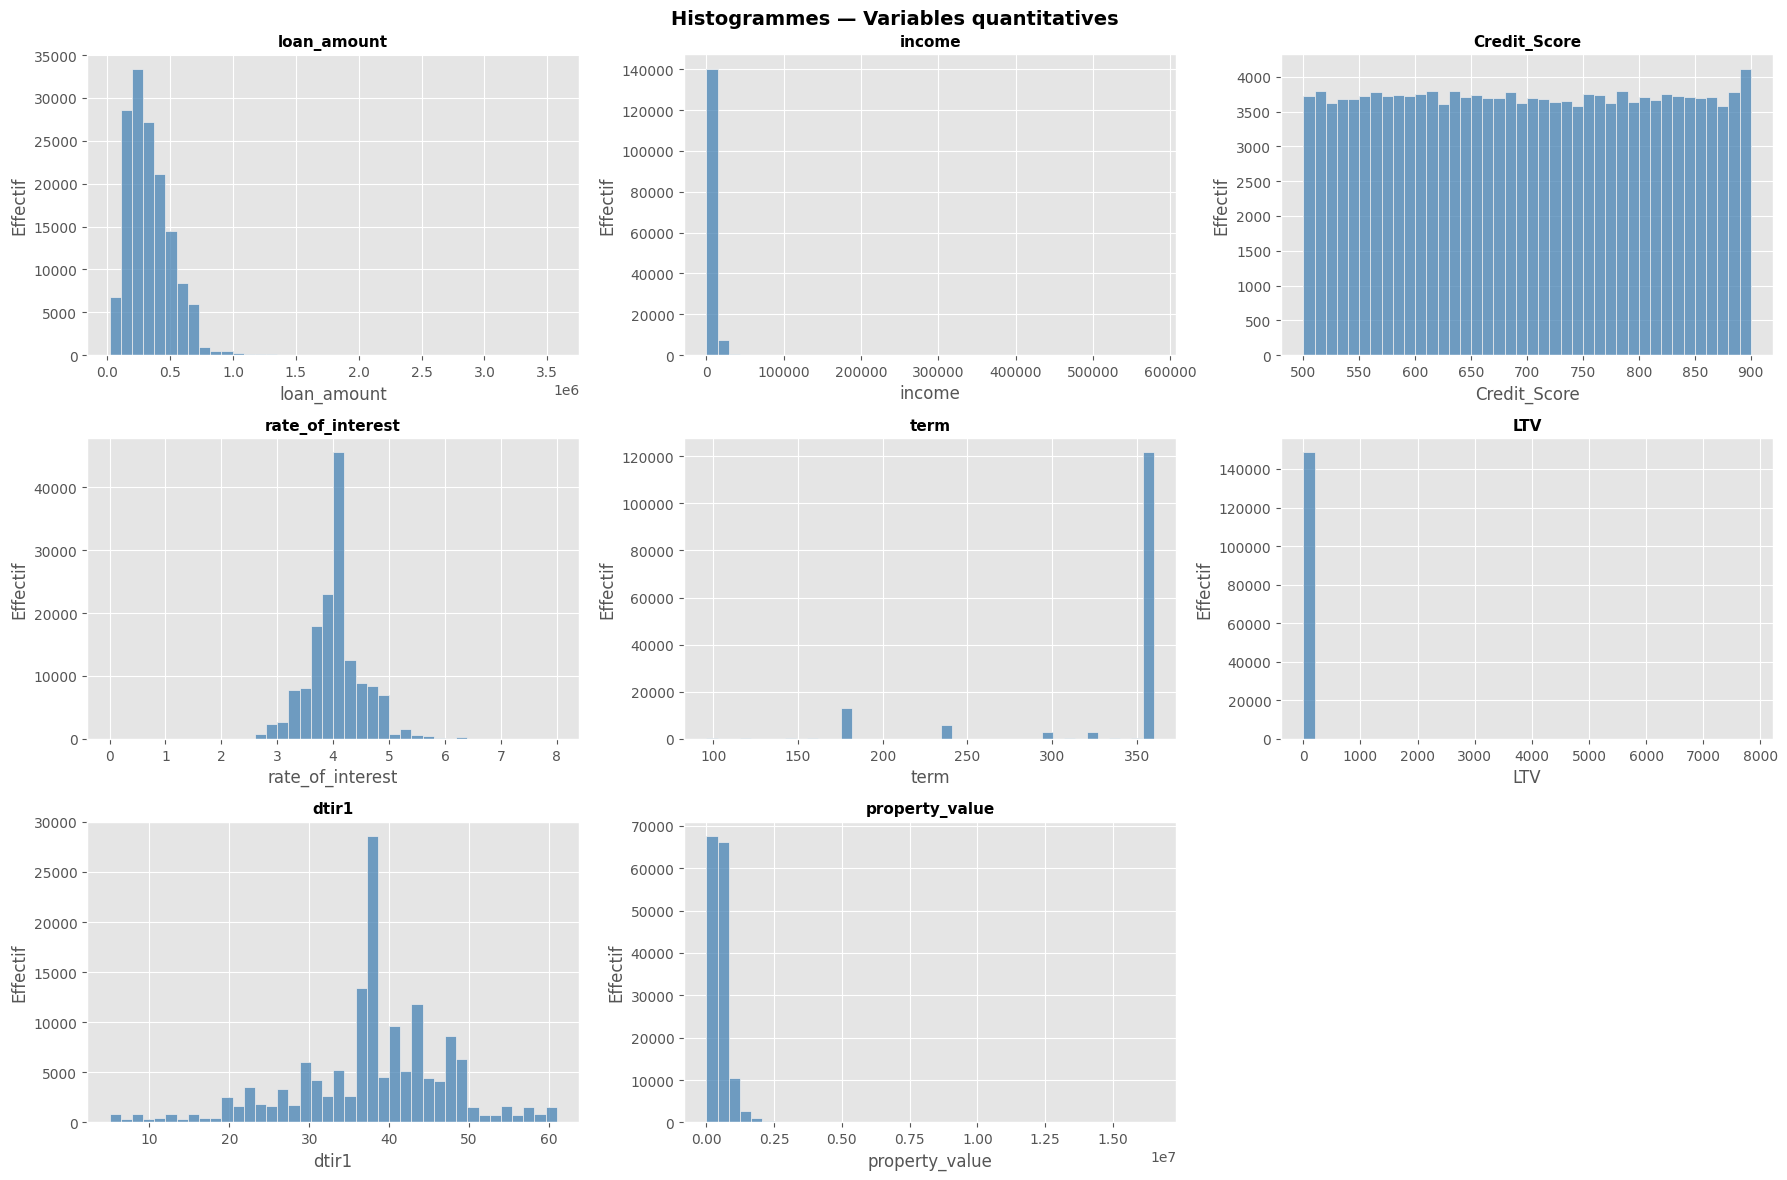

In [13]:
# Histogrammes des variables quantitatives
ncols = 3
nrows = (len(quantitative) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(quantitative):
    sns.histplot(df[col], kde=False, bins=40, ax=axes[i], color='steelblue')
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Effectif')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Histogrammes — Variables quantitatives', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Histogrammes + courbe de densité KDE
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(quantitative):
    sns.histplot(df[col], kde=True, bins=40, ax=axes[i], color='teal')
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Densité')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Histogrammes + KDE — Variables quantitatives', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

KeyboardInterrupt: 

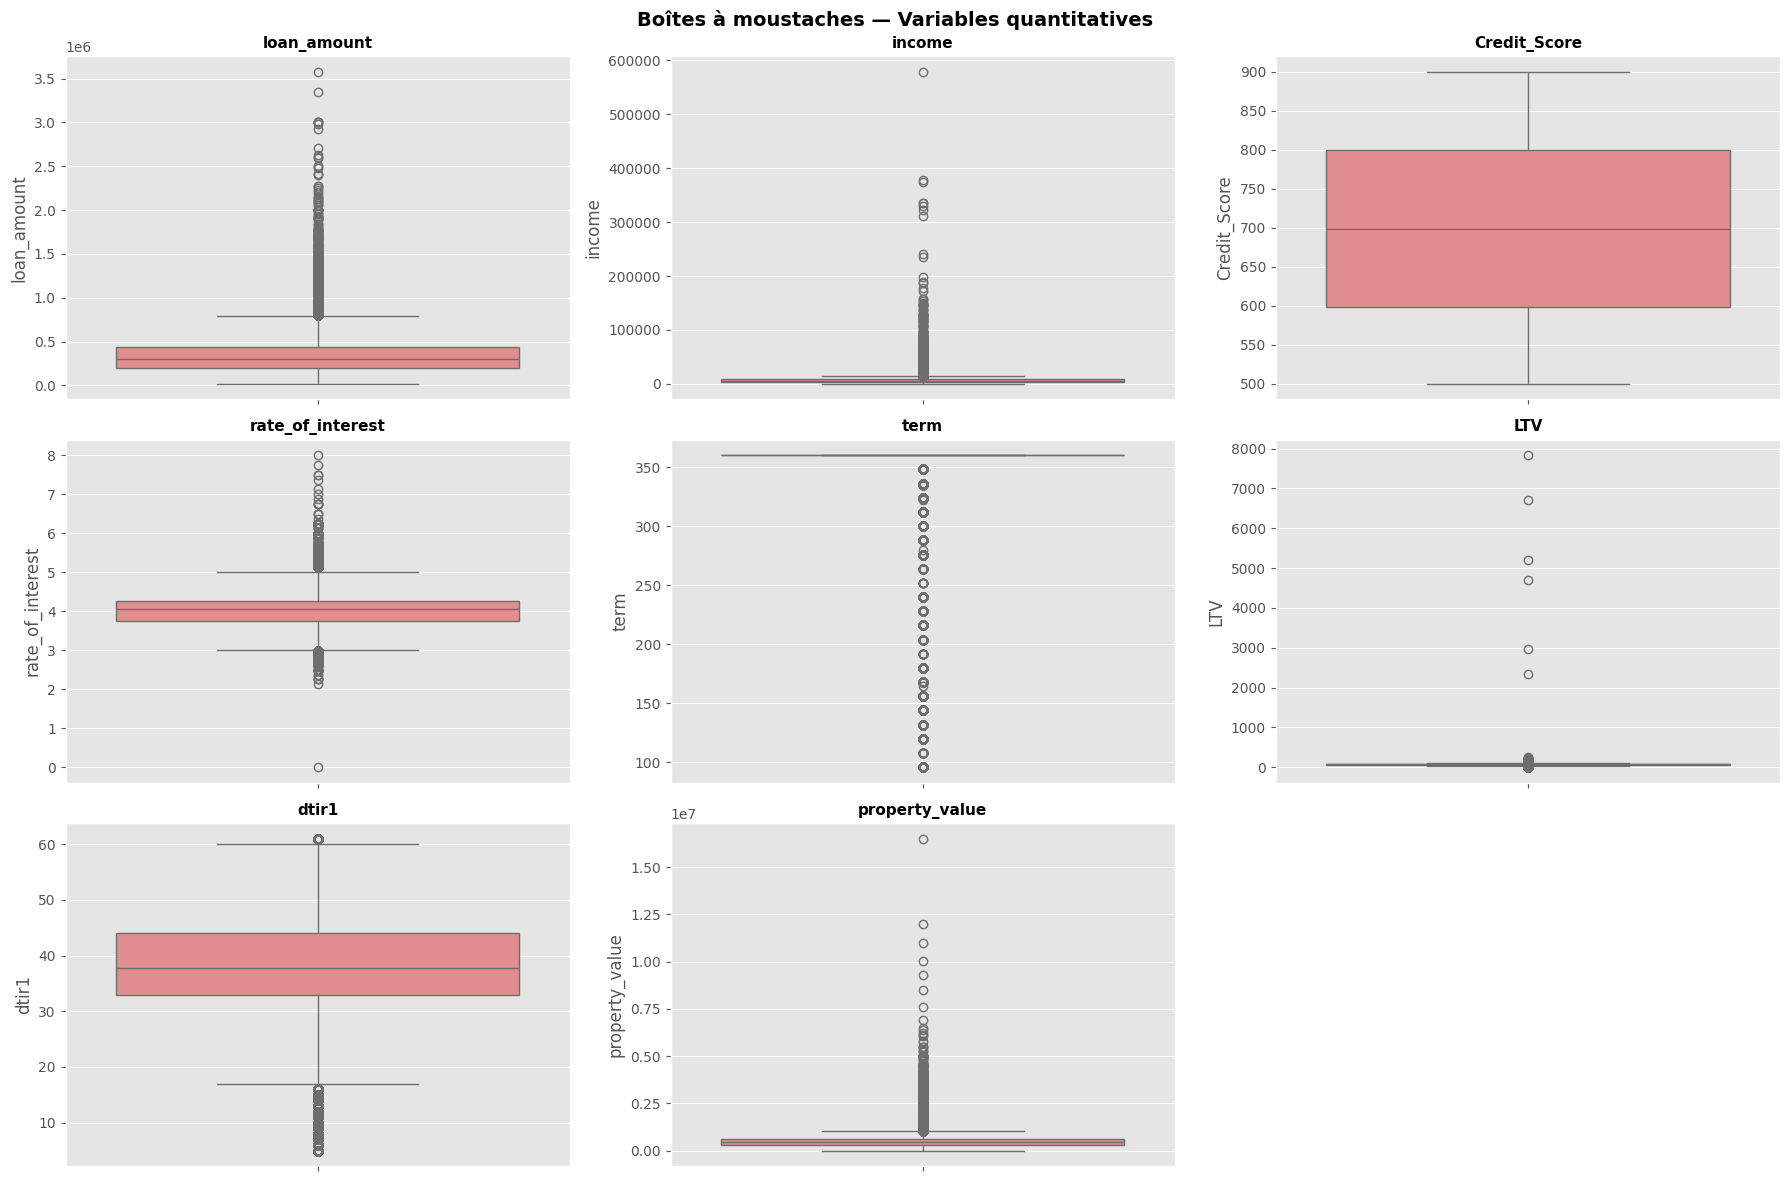

In [ ]:
# Boîtes à moustaches — variables quantitatives (détection des valeurs aberrantes)
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(quantitative):
    sns.boxplot(y=df[col], ax=axes[i], color='lightcoral')
    axes[i].set_title(col, fontsize=11, fontweight='bold')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boîtes à moustaches — Variables quantitatives', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

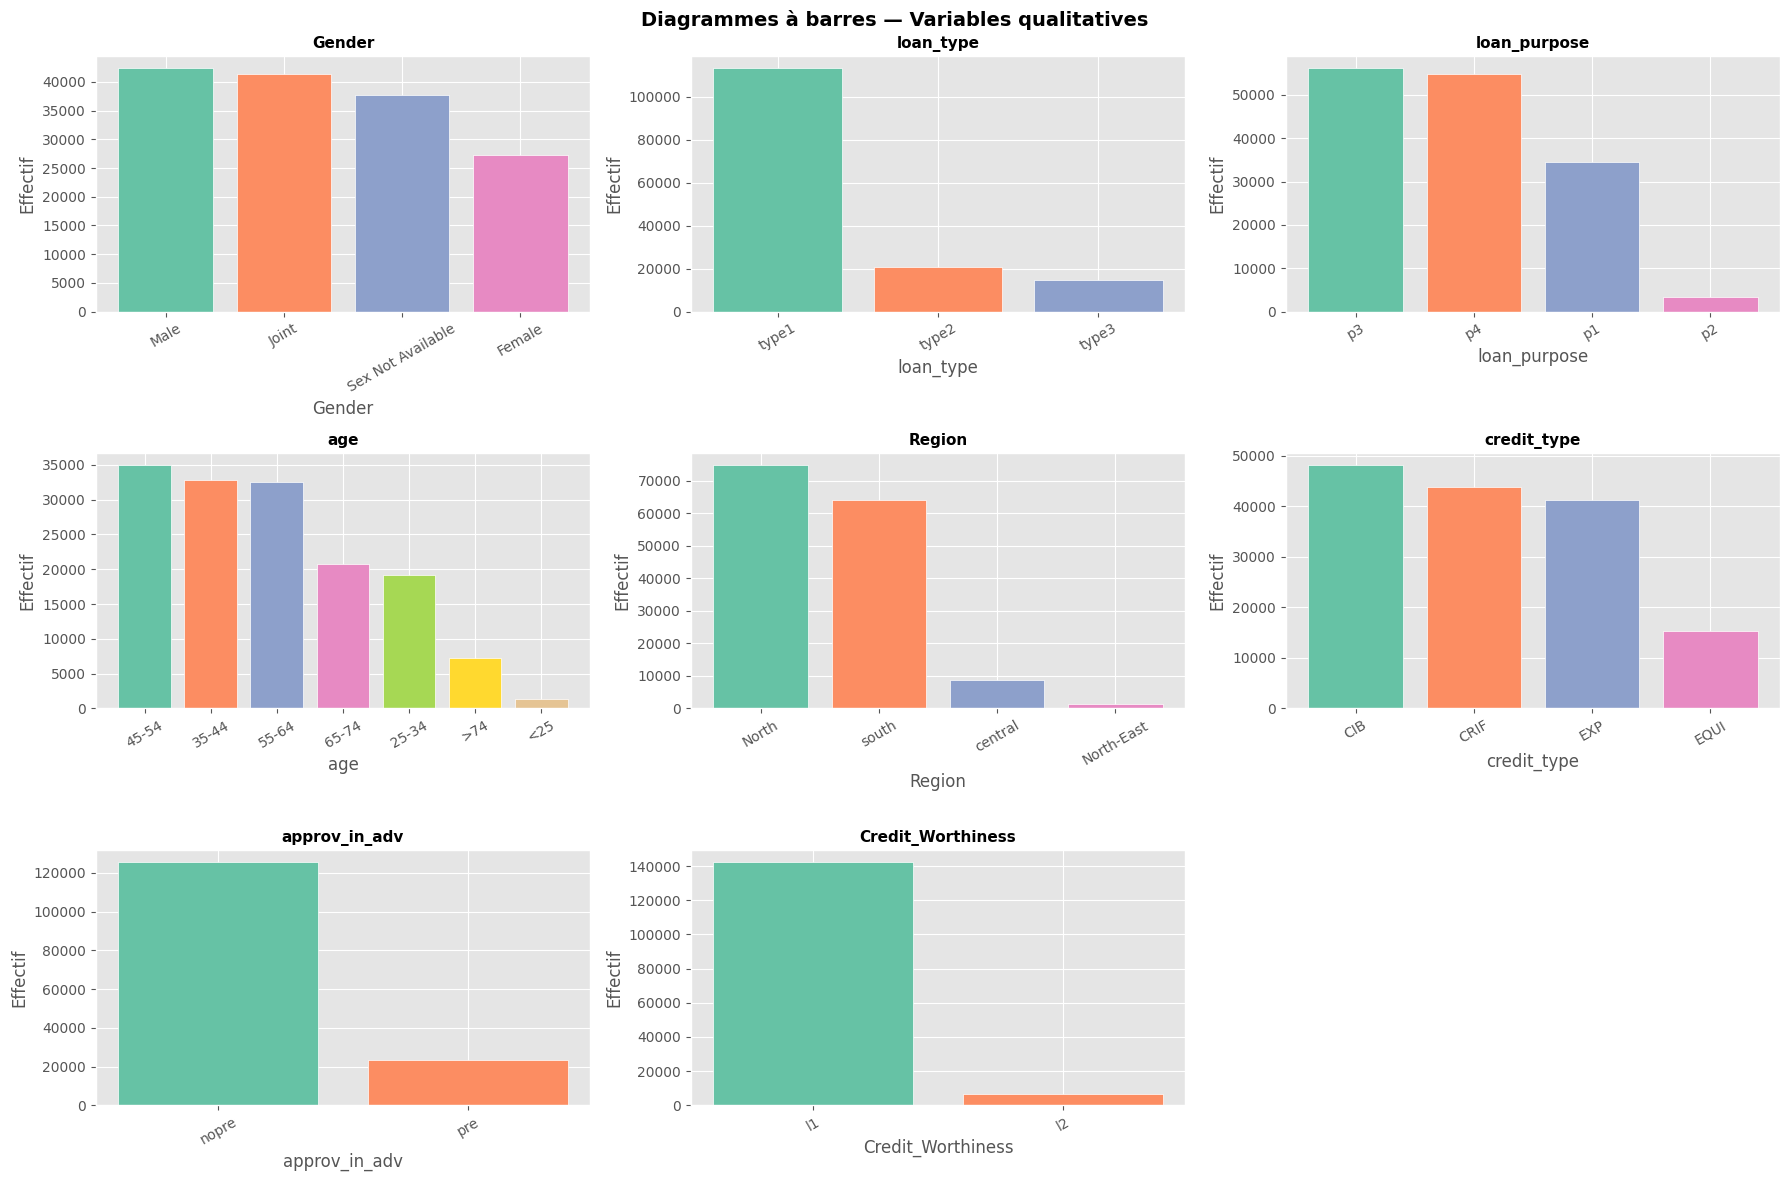

In [ ]:
# Diagrammes à barres — variables qualitatives
ncols_q = 3
nrows_q = (len(qualitative) + ncols_q - 1) // ncols_q
fig, axes = plt.subplots(nrows_q, ncols_q, figsize=(18, nrows_q * 4))
axes = axes.flatten()

for i, col in enumerate(qualitative):
    counts = df[col].value_counts()
    axes[i].bar(counts.index.astype(str), counts.values,
                color=list(plt.cm.Set2.colors[:len(counts)]), edgecolor='white')
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Effectif')
    axes[i].tick_params(axis='x', rotation=30)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Diagrammes à barres — Variables qualitatives', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

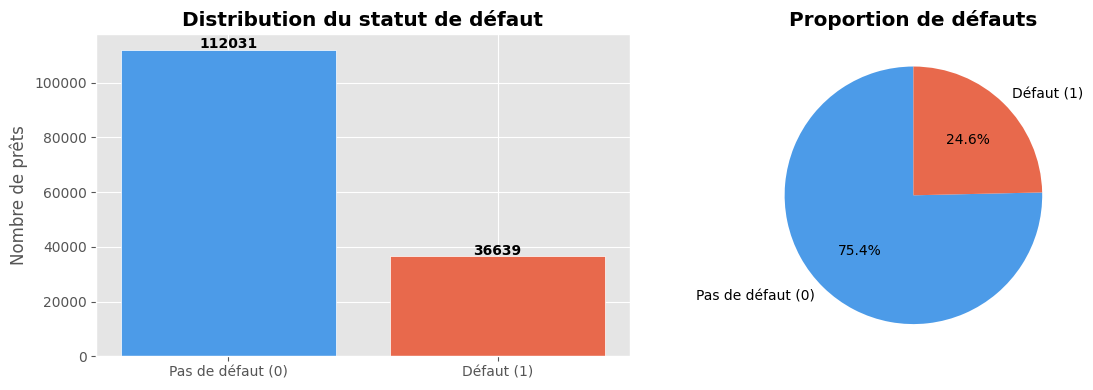

In [ ]:
# Distribution de la variable cible
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df[target].value_counts()
axes[0].bar(['Pas de défaut (0)', 'Défaut (1)'], counts.values,
            color=['#4C9BE8', '#E8694C'], edgecolor='white')
axes[0].set_title('Distribution du statut de défaut', fontweight='bold')
axes[0].set_ylabel('Nombre de prêts')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 500, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=['Pas de défaut (0)', 'Défaut (1)'],
            colors=['#4C9BE8', '#E8694C'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Proportion de défauts', fontweight='bold')

plt.tight_layout()
plt.show()

---
# 5. Analyse multivariée — Variables quantitatives


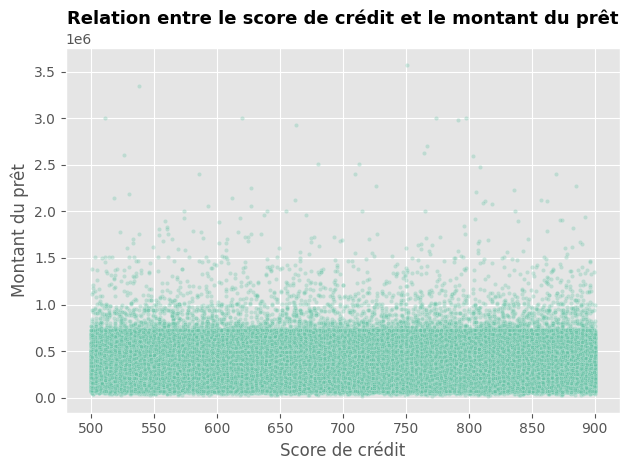

In [ ]:
# Nuage de points — Credit_Score vs loan_amount
sns.scatterplot(x='Credit_Score', y='loan_amount', data=df,
                alpha=0.3, s=10)
plt.title('Relation entre le score de crédit et le montant du prêt', fontsize=13, fontweight='bold')
plt.xlabel('Score de crédit')
plt.ylabel('Montant du prêt')
plt.tight_layout()
plt.show()

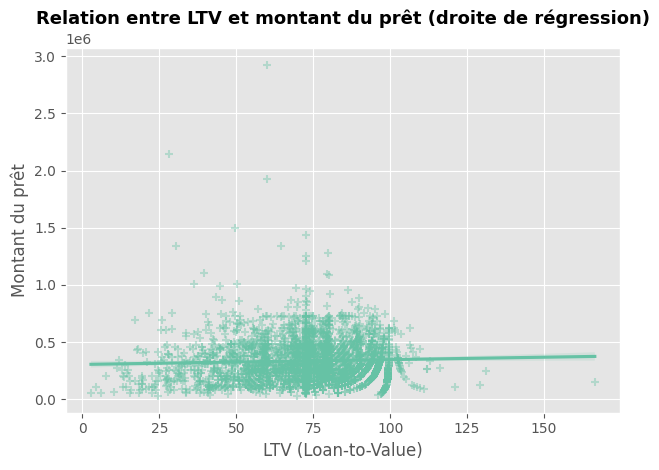

In [ ]:
# Nuage de points avec droite de régression — LTV vs loan_amount
sns.regplot(x='LTV', y='loan_amount', data=df.sample(3000, random_state=42),
            fit_reg=True, marker='+', scatter_kws={'alpha': 0.4})
plt.title('Relation entre LTV et montant du prêt (droite de régression)', fontsize=13, fontweight='bold')
plt.xlabel('LTV (Loan-to-Value)')
plt.ylabel('Montant du prêt')
plt.tight_layout()
plt.show()

In [ ]:
# Coefficient de corrélation de Pearson entre paires de variables clés
pairs = [
    ('Credit_Score', 'loan_amount'),
    ('LTV', 'loan_amount'),
    ('income', 'loan_amount'),
    ('dtir1', 'rate_of_interest'),
    ('Credit_Score', 'rate_of_interest'),
]

print(f"{'Paire de variables':<45} {'Corrélation de Pearson':>25} {'p-valeur':>12}")
print('-' * 85)
for x, y in pairs:
    r, p = stats.pearsonr(df[x], df[y])
    print(f"{x + ' vs ' + y:<45} {r:>25.4f} {p:>12.4e}")

Paire de variables                               Corrélation de Pearson     p-valeur
-------------------------------------------------------------------------------------
Credit_Score vs loan_amount                                      0.0044   8.7026e-02
LTV vs loan_amount                                               0.0364   8.4421e-45
income vs loan_amount                                            0.4433   0.0000e+00
dtir1 vs rate_of_interest                                        0.0424   3.8674e-60
Credit_Score vs rate_of_interest                                -0.0012   6.5618e-01


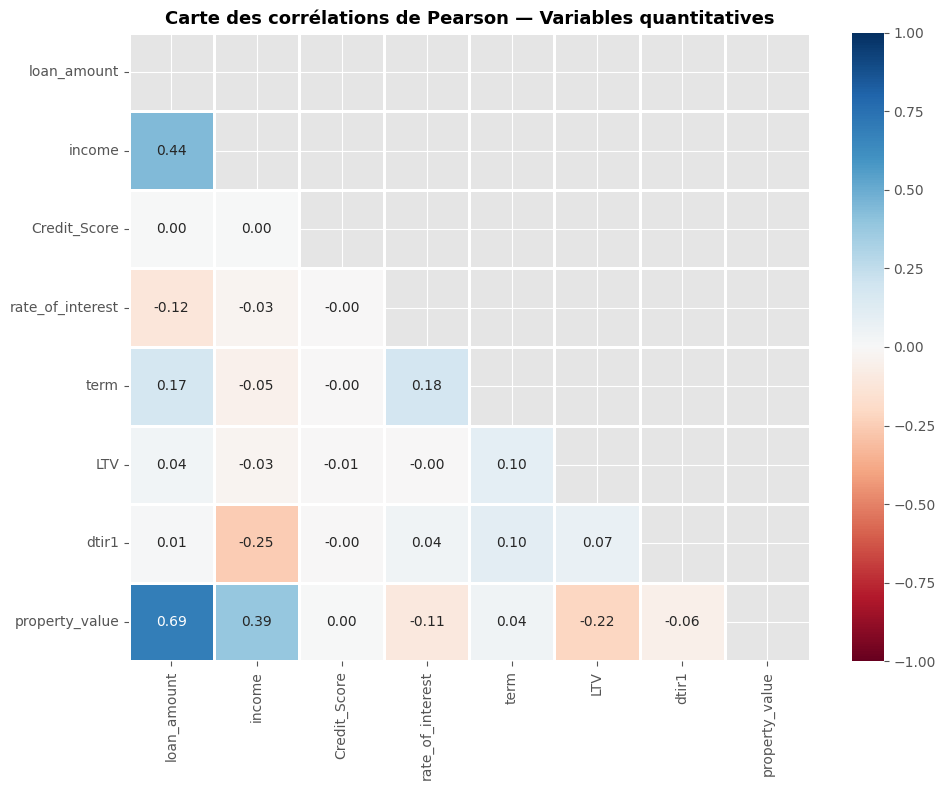

In [ ]:
# Carte de chaleur des corrélations de Pearson
plt.figure(figsize=(10, 8))

corr = df[quantitative].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, center=0, cmap='RdBu',
            linewidths=1, annot=True, fmt='.2f', vmin=-1, vmax=1)
plt.title('Carte des corrélations de Pearson — Variables quantitatives',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

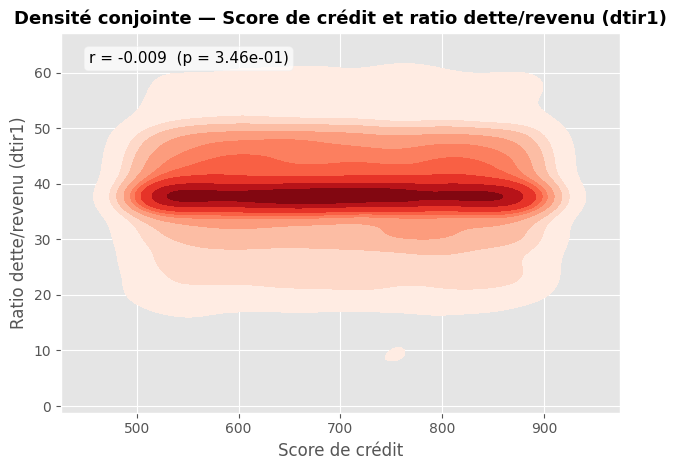

In [ ]:
# Densité de points 2D (KDE 2D) — Credit_Score vs dtir1
sample = df.sample(10000, random_state=42)

sns.kdeplot(x='Credit_Score', y='dtir1', cmap='Reds',
            fill=True, data=sample)
plt.title('Densité conjointe — Score de crédit et ratio dette/revenu (dtir1)',
          fontsize=13, fontweight='bold')
plt.xlabel('Score de crédit')
plt.ylabel('Ratio dette/revenu (dtir1)')
r, p = stats.pearsonr(sample['Credit_Score'], sample['dtir1'])
plt.annotate(f'r = {r:.3f}  (p = {p:.2e})', xy=(0.05, 0.92),
             xycoords='axes fraction', fontsize=11,
             bbox=dict(boxstyle='round', fc='white', alpha=0.7))
plt.tight_layout()
plt.show()

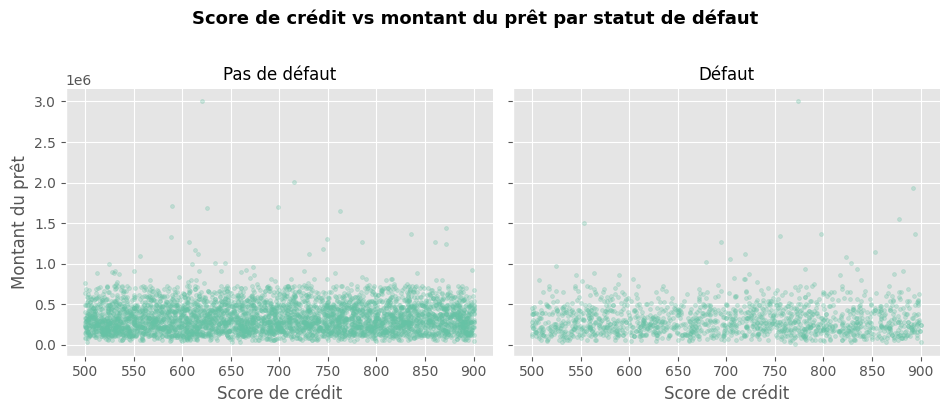

Pas de défaut — Pearson r = 0.0028, p = 3.4570e-01
Défaut — Pearson r = 0.0091, p = 7.9971e-02


In [ ]:
# FacetGrid — relation Credit_Score vs loan_amount selon le statut de défaut
sample2 = df.sample(6000, random_state=1).copy()
sample2['Status_label'] = sample2['Status'].map({0: 'Pas de défaut', 1: 'Défaut'})

g = sns.FacetGrid(sample2, col='Status_label', height=4, aspect=1.2)
g.map(plt.scatter, 'Credit_Score', 'loan_amount', alpha=0.3, s=8)
g.set_axis_labels('Score de crédit', 'Montant du prêt')
g.set_titles(col_template='{col_name}')
g.figure.suptitle('Score de crédit vs montant du prêt par statut de défaut',
                  y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

for status, label in [(0, 'Pas de défaut'), (1, 'Défaut')]:
    sub = df[df['Status'] == status]
    r, p = stats.pearsonr(sub['Credit_Score'], sub['loan_amount'])
    print(f'{label} — Pearson r = {r:.4f}, p = {p:.4e}')

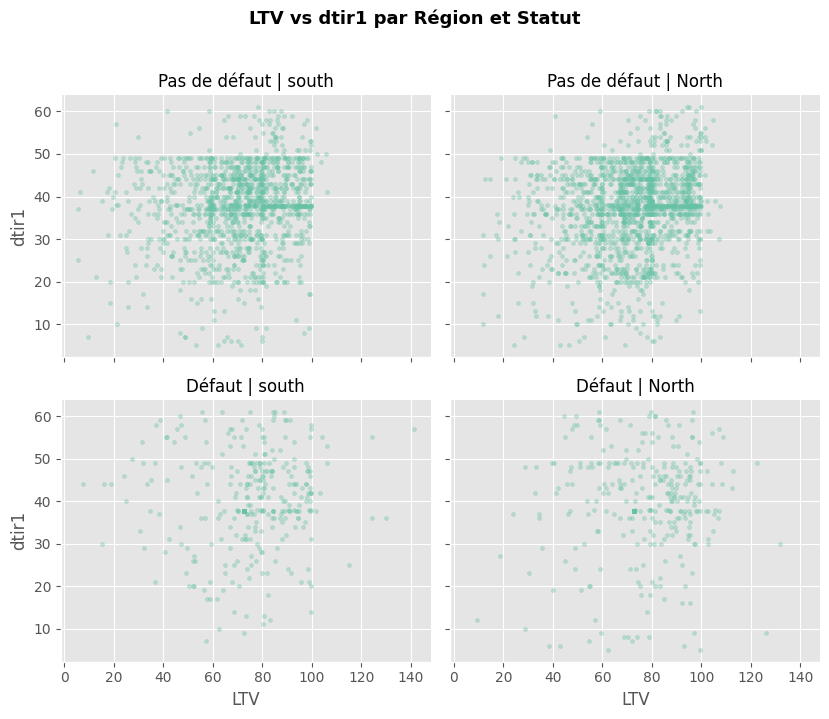

In [ ]:
# FacetGrid — relation LTV vs dtir1 par région ET statut
sample3 = df[df['Region'].isin(['south', 'North'])].sample(4000, random_state=7).copy()
sample3['Status_label'] = sample3['Status'].map({0: 'Pas de défaut', 1: 'Défaut'})

g2 = sns.FacetGrid(sample3, col='Region', row='Status_label', height=3.5, aspect=1.2)
g2.map(plt.scatter, 'LTV', 'dtir1', alpha=0.35, s=8)
g2.set_axis_labels('LTV', 'dtir1')
g2.set_titles(col_template='{col_name}', row_template='{row_name}')
g2.figure.suptitle('LTV vs dtir1 par Région et Statut', y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
# 6. Analyse multivariée — Variables qualitatives (Tableaux de contingence)


In [ ]:
# Tableau de contingence — loan_type vs loan_purpose
print('=== Tableau de contingence brut : loan_type × loan_purpose ===')
pd.crosstab(df['loan_type'], df['loan_purpose'])

=== Tableau de contingence brut : loan_type × loan_purpose ===


loan_purpose,p1,p2,p3,p4
loan_type,,,,
type1,26304,2827,41398,42644
type2,5677,438,8579,6068
type3,2548,9,6091,6087


In [ ]:
# Normalisé par lignes (%)
print('=== Normalisé par lignes (%) ===')
pd.crosstab(df['loan_type'], df['loan_purpose']).apply(lambda z: z / z.sum() * 100, axis=1).round(2)

=== Normalisé par lignes (%) ===


loan_purpose,p1,p2,p3,p4
loan_type,,,,
type1,23.24,2.50,36.58,37.68
type2,27.34,2.11,41.32,29.23
type3,17.29,0.06,41.34,41.31


In [ ]:
# Normalisé par colonnes (%)
print('=== Normalisé par colonnes (%) ===')
pd.crosstab(df['loan_type'], df['loan_purpose']).apply(lambda z: z / z.sum() * 100, axis=0).round(2)

=== Normalisé par colonnes (%) ===


loan_purpose,p1,p2,p3,p4
loan_type,,,,
type1,76.18,86.35,73.84,77.82
type2,16.44,13.38,15.30,11.07
type3,7.38,0.27,10.86,11.11


In [ ]:
# Tableau de contingence — Region × Status (variable cible)
print('=== Region × Status (%) par ligne ===')
ct = pd.crosstab(df['Region'], df['Status'])
ct.columns = ['Pas de défaut', 'Défaut']
ct_pct = ct.apply(lambda z: z / z.sum() * 100, axis=1).round(2)
ct_pct

=== Region × Status (%) par ligne ===


,Pas de défaut,Défaut
Region,,
North,77.49,22.51
North-East,69.55,30.45
central,72.46,27.54
south,73.37,26.63


In [ ]:
# Tableau de contingence à 3 variables — Gender × Credit_Worthiness × Status
print('=== Gender × Credit_Worthiness × Status (proportions) ===')
pd.crosstab([df['Gender'], df['Credit_Worthiness']], df['Status']).apply(
    lambda z: z / z.sum(), axis=1).round(3)

=== Gender × Credit_Worthiness × Status (proportions) ===


Status                                   0      1
Gender            Credit_Worthiness              
Female            l1                 0.752  0.248
                  l2                 0.668  0.332
Joint             l1                 0.811  0.189
                  l2                 0.749  0.251
Male              l1                 0.742  0.258
                  l2                 0.644  0.356
Sex Not Available l1                 0.717  0.283
                  l2                 0.658  0.342

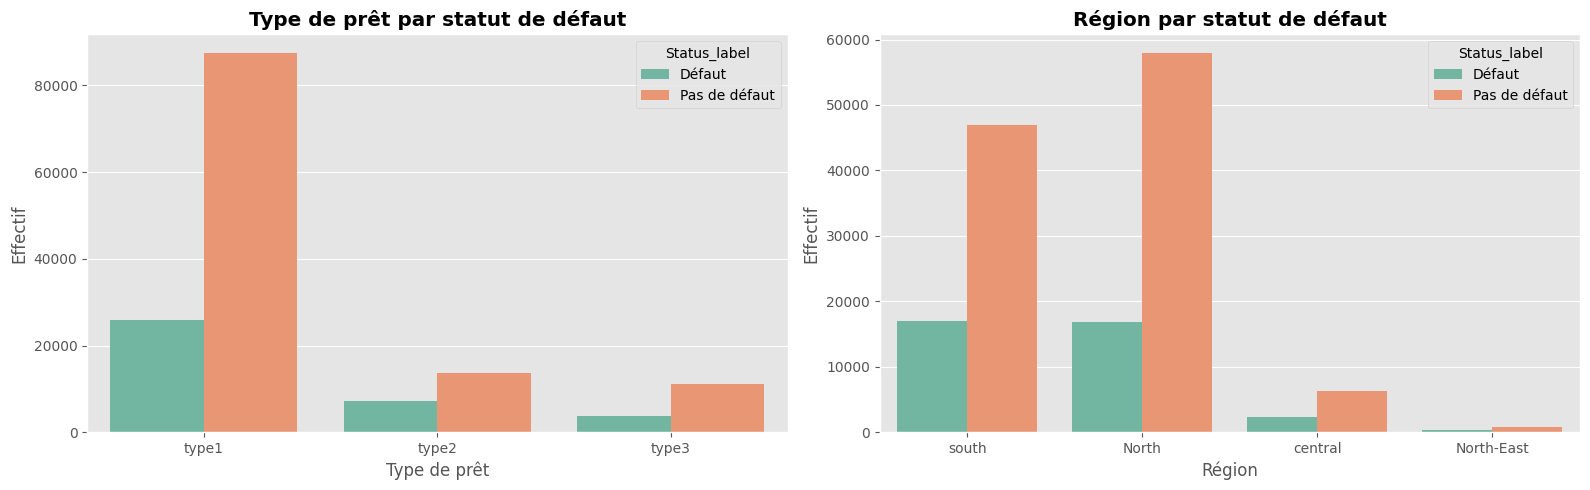

In [ ]:
# Visualisation — countplot loan_type par statut
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

df_labeled = df.copy()
df_labeled['Status_label'] = df_labeled['Status'].map({0: 'Pas de défaut', 1: 'Défaut'})

sns.countplot(x='loan_type', hue='Status_label', data=df_labeled, ax=axes[0])
axes[0].set_title('Type de prêt par statut de défaut', fontweight='bold')
axes[0].set_xlabel('Type de prêt')
axes[0].set_ylabel('Effectif')

sns.countplot(x='Region', hue='Status_label', data=df_labeled, ax=axes[1])
axes[1].set_title('Région par statut de défaut', fontweight='bold')
axes[1].set_xlabel('Région')
axes[1].set_ylabel('Effectif')

plt.tight_layout()
plt.show()

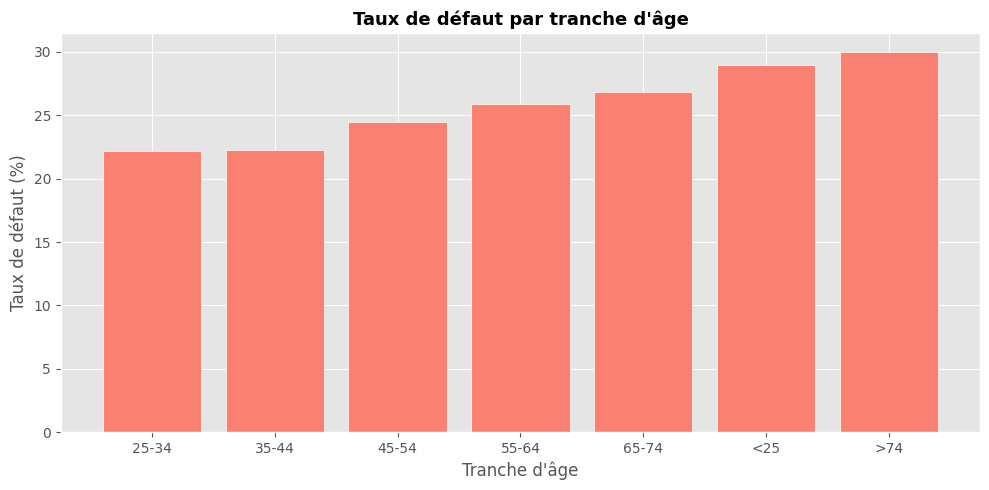

In [ ]:
# Taux de défaut par tranche d'âge
age_default = df.groupby('age')[target].mean().mul(100).round(2).reset_index()
age_default.columns = ['Tranche d\'âge', 'Taux de défaut (%)']
age_order = ['<25', '25-34', '35-44', '45-54', '55-64', '>64', 'Unknown']
age_order = [a for a in age_order if a in age_default['Tranche d\'âge'].values]

plt.figure(figsize=(10, 5))
plt.bar(age_default['Tranche d\'âge'], age_default['Taux de défaut (%)'],
        color='salmon', edgecolor='white')
plt.title('Taux de défaut par tranche d\'âge', fontsize=13, fontweight='bold')
plt.xlabel('Tranche d\'âge')
plt.ylabel('Taux de défaut (%)')
plt.tight_layout()
plt.show()

---
# 7. Analyse multivariée — Variables qualitatives × quantitatives


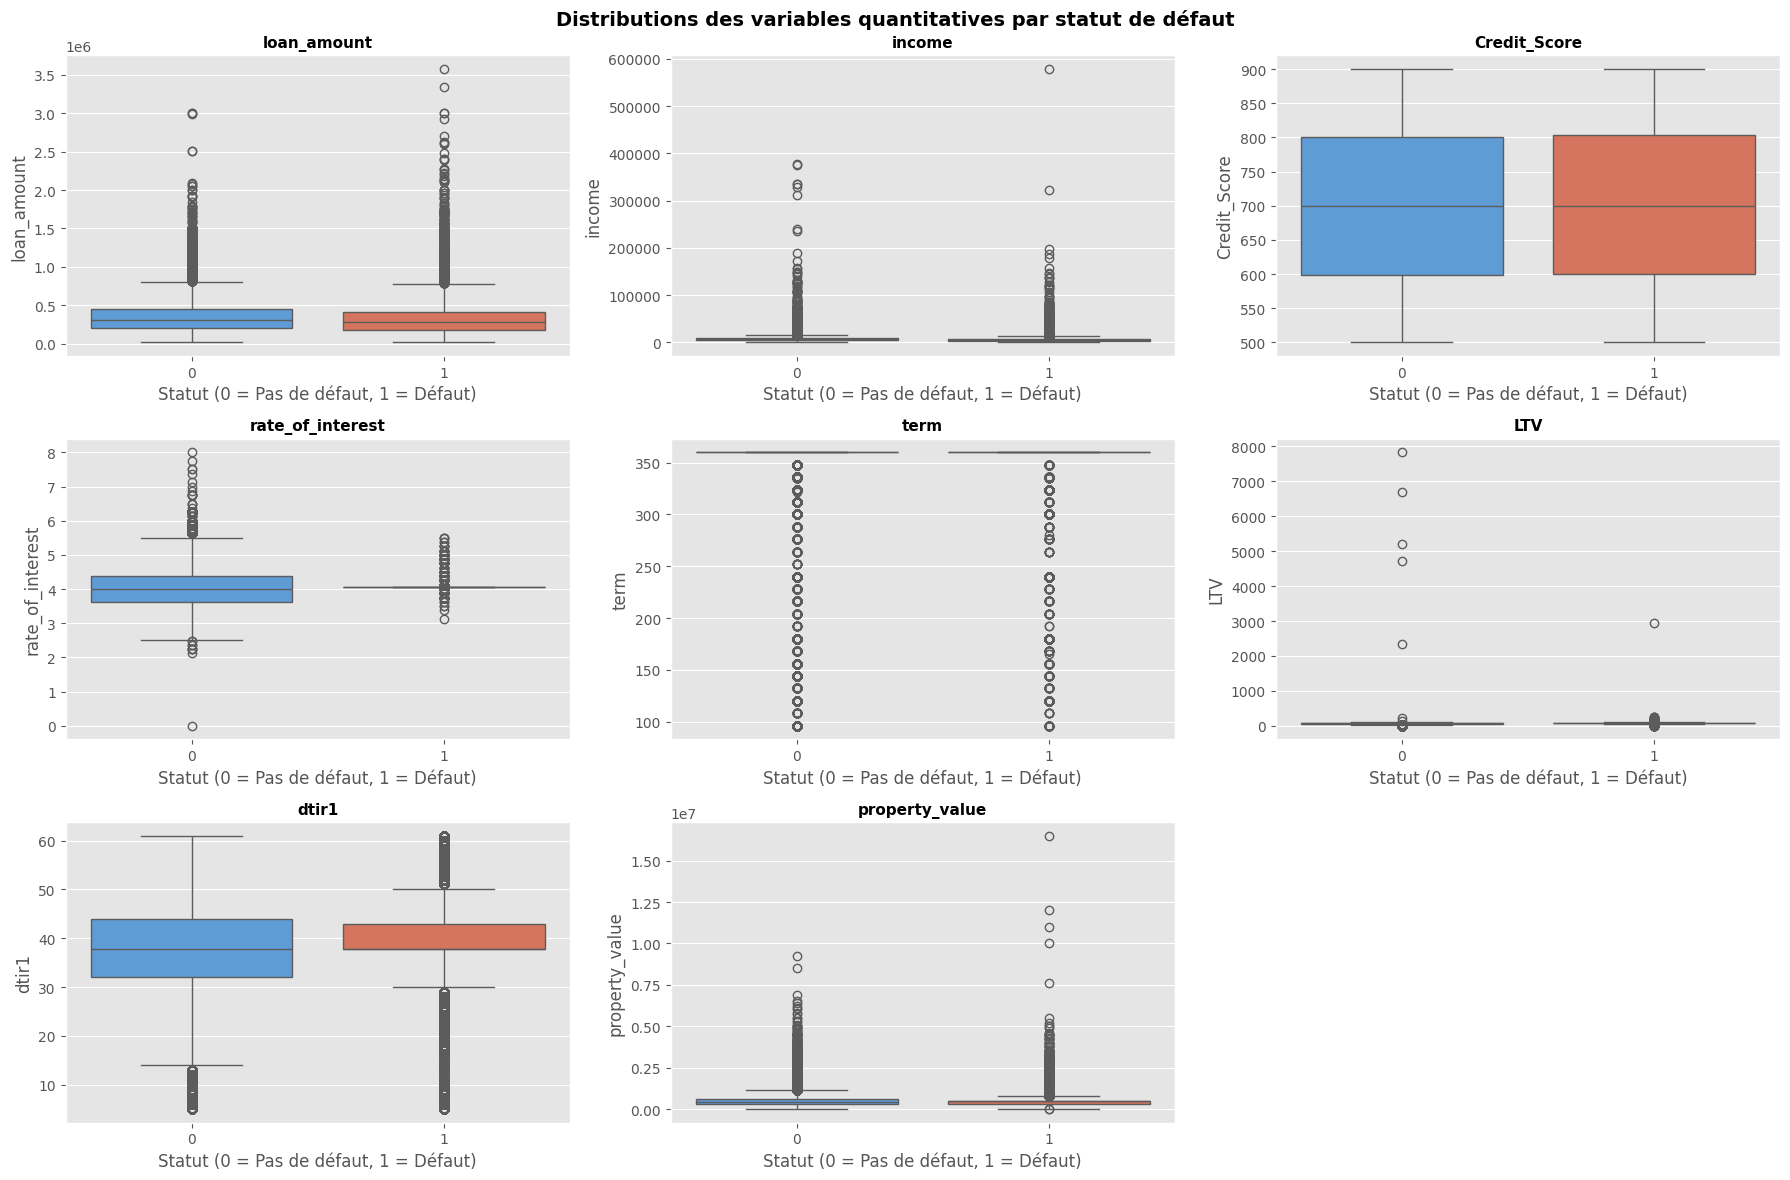

In [ ]:
# Boîtes à moustaches — variables quantitatives par statut de défaut
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(quantitative):
    sns.boxplot(x=target, y=col, data=df_labeled, hue='Status_label',
                palette={'Pas de défaut': '#4C9BE8', 'Défaut': '#E8694C'},
                ax=axes[i], legend=False)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Statut (0 = Pas de défaut, 1 = Défaut)')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distributions des variables quantitatives par statut de défaut',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

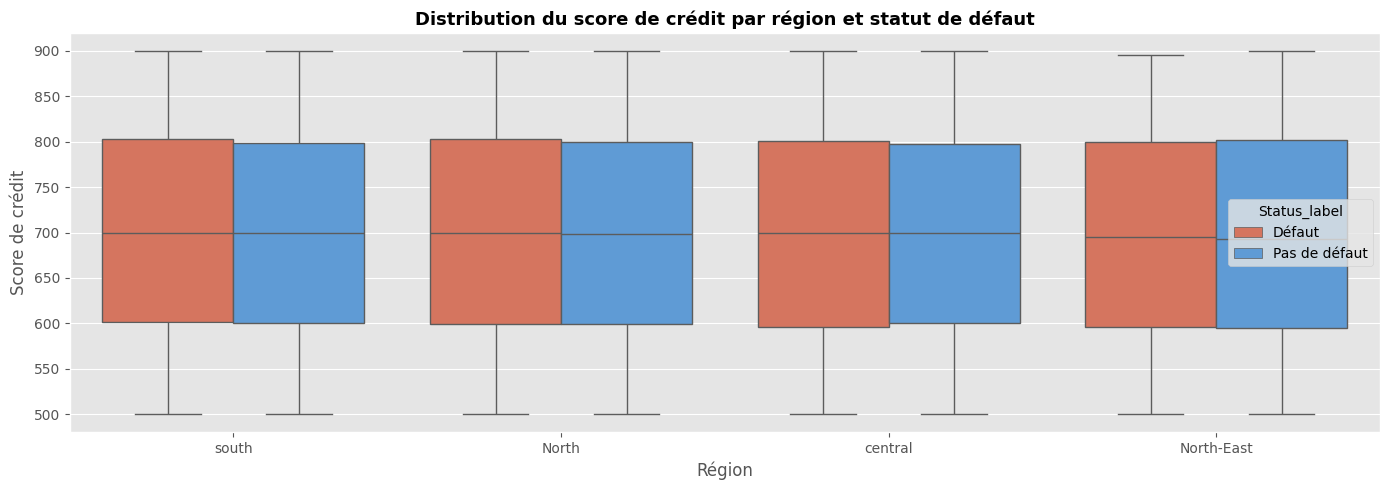

In [ ]:
# Boîtes à moustaches — Credit_Score par région et statut
plt.figure(figsize=(14, 5))
sns.boxplot(x='Region', y='Credit_Score', hue='Status_label',
            data=df_labeled, palette={'Pas de défaut': '#4C9BE8', 'Défaut': '#E8694C'})
plt.title('Distribution du score de crédit par région et statut de défaut',
          fontsize=13, fontweight='bold')
plt.xlabel('Région')
plt.ylabel('Score de crédit')
plt.tight_layout()
plt.show()

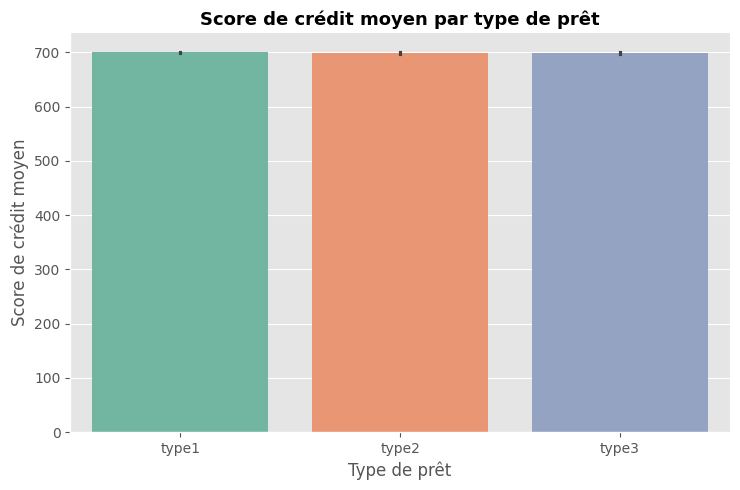

In [ ]:
# catplot — score de crédit moyen par type de prêt
sns.catplot(x='loan_type', y='Credit_Score', kind='bar',
            data=df, height=5, aspect=1.5,
            palette='Set2')
plt.title('Score de crédit moyen par type de prêt', fontsize=13, fontweight='bold')
plt.xlabel('Type de prêt')
plt.ylabel('Score de crédit moyen')
plt.tight_layout()
plt.show()

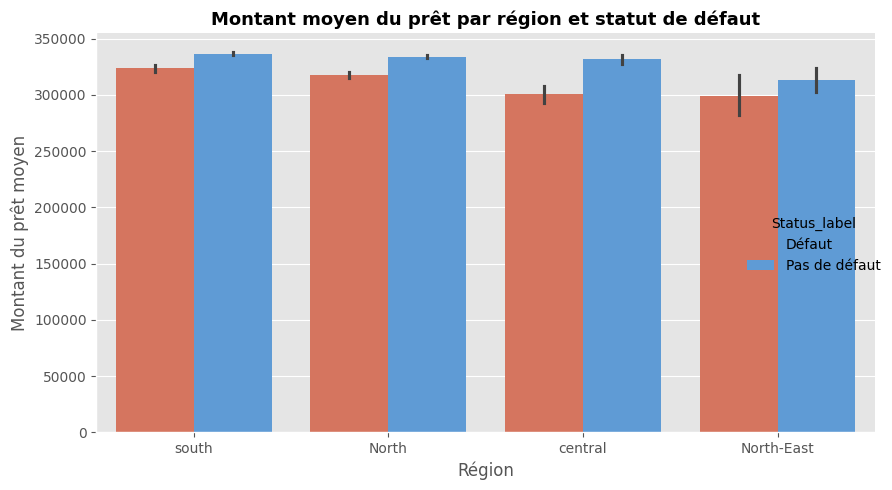

In [ ]:
# catplot — montant du prêt par région et statut
sns.catplot(x='Region', y='loan_amount', hue='Status_label',
            kind='bar', data=df_labeled, height=5, aspect=1.5,
            palette={'Pas de défaut': '#4C9BE8', 'Défaut': '#E8694C'})
plt.title('Montant moyen du prêt par région et statut de défaut',
          fontsize=13, fontweight='bold')
plt.xlabel('Région')
plt.ylabel('Montant du prêt moyen')
plt.tight_layout()
plt.show()

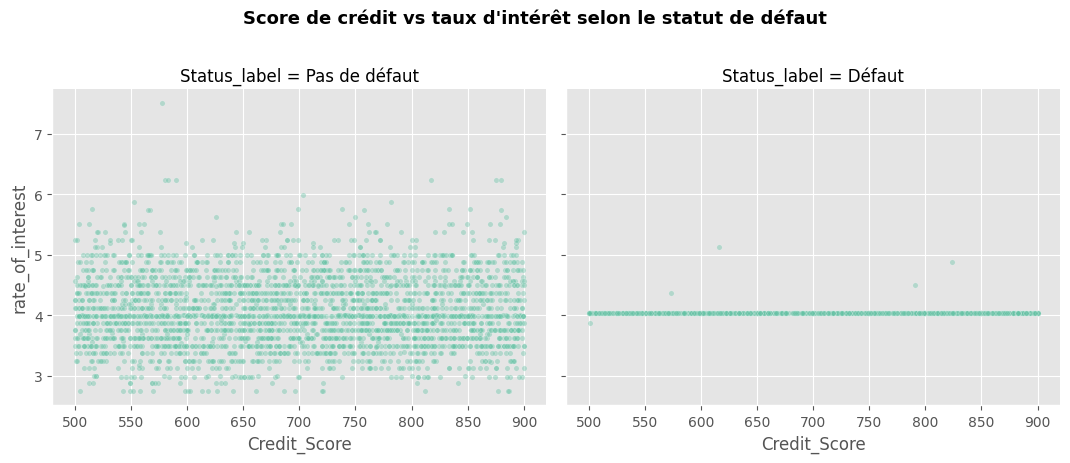

In [ ]:
# relplot — Credit_Score vs rate_of_interest selon le statut
sample4 = df_labeled.sample(4000, random_state=5)

sns.relplot(x='Credit_Score', y='rate_of_interest', col='Status_label',
            kind='scatter', data=sample4, alpha=0.4, s=15,
            height=4.5, aspect=1.2)
plt.suptitle('Score de crédit vs taux d\'intérêt selon le statut de défaut',
             y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

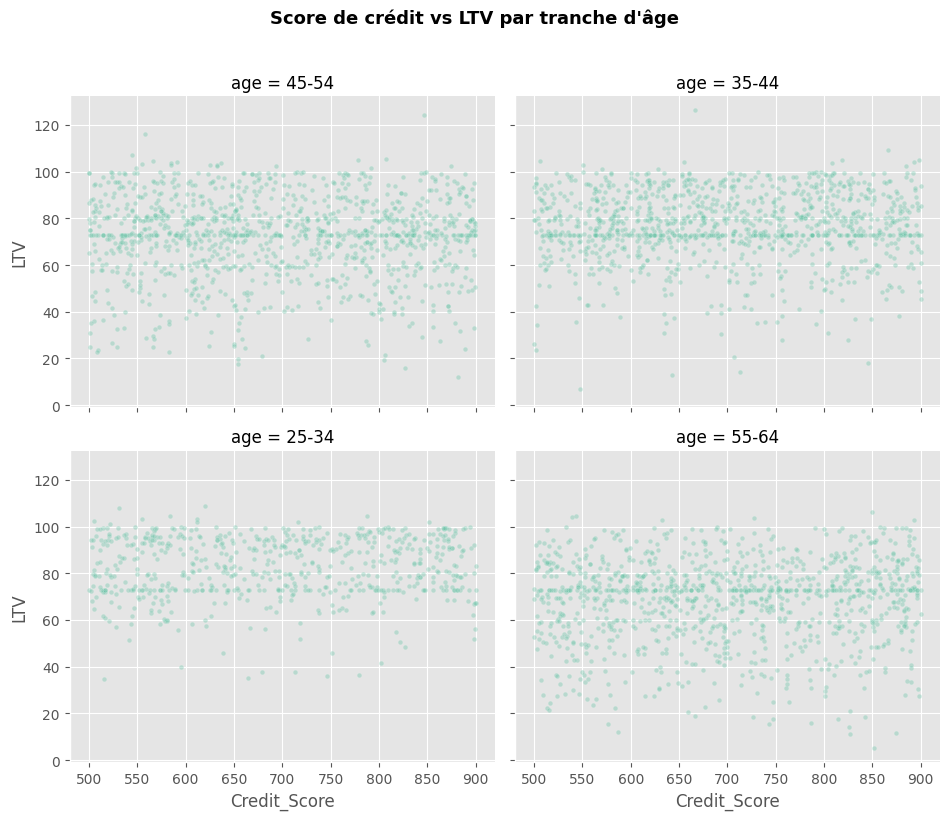

In [ ]:
# relplot — LTV vs Credit_Score par âge
age_groups = ['25-34', '35-44', '45-54', '55-64']
sample5 = df[df['age'].isin(age_groups)].sample(4000, random_state=42)

sns.relplot(x='Credit_Score', y='LTV', col='age', kind='scatter',
            data=sample5, alpha=0.35, s=12, col_wrap=2,
            height=4, aspect=1.2)
plt.suptitle('Score de crédit vs LTV par tranche d\'âge',
             y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Statistiques groupées par statut — variables quantitatives
print('=== Statistiques par statut de défaut ===')
df.groupby(target)[quantitative].agg(['mean', 'median']).T

=== Statistiques par statut de défaut ===


Status                               0              1
loan_amount      mean    334990.774875  319275.184912
                 median  306500.000000  276500.000000
income           mean      7186.595387    6256.341681
                 median    6360.000000    5040.000000
Credit_Score     mean       699.523793     700.600344
                 median     699.000000     700.000000
rate_of_interest mean         4.044931       4.047141
                 median       3.990000       4.045476
term             mean       335.144590     335.112095
                 median     360.000000     360.000000
LTV              mean        72.064769      74.830853
                 median      74.504405      72.746457
dtir1            mean        37.394622      38.767383
                 median      37.732932      37.732932
property_value   mean    505605.928600  474311.082676
                 median  428000.000000  497893.465696

---
# 8. Synthèse et Conclusions

## Ce que l'analyse révèle sur le défaut de remboursement

### Déséquilibre des classes
Le jeu de données présente un **déséquilibre** : environ 75 % des prêts n'ont pas fait défaut (Status = 0) contre ~25 % en défaut (Status = 1). Cela devra être pris en compte dans tout modèle prédictif (rééchantillonnage, poids de classe, etc.).

### Variables quantitatives 
- **Credit_Score** : les emprunteurs en défaut ont un score de crédit **significativement plus bas** (médiane inférieure observée dans les boxplots groupés).
- **rate_of_interest** : le taux d'intérêt est **plus élevé** chez les emprunteurs en défaut — probablement parce qu'ils ont été jugés plus risqués dès l'octroi.
- **LTV (Loan-to-Value)** : les ratios LTV élevés sont associés à un risque de défaut plus important.
- **dtir1 (Debt-to-Income Ratio)** : les emprunteurs en défaut affichent un ratio d'endettement plus élevé.
- La carte de corrélation montre que **loan_amount et property_value** sont très corrélés, et que **Credit_Score et rate_of_interest** sont légèrement corrélés négativement.

### Variables qualitatives 
- Les **tableaux de contingence** Region × Status révèlent des disparités géographiques dans le taux de défaut.
- Le **type de prêt** (loan_type) et la **solvabilité** (Credit_Worthiness) sont des facteurs discriminants importants.
- Les **tranches d'âge** jeunes (<25, 25-34) présentent généralement un taux de défaut plus élevé.

### Variables à retenir pour un modèle prédictif
Les variables les plus prometteuses, identifiées via cette analyse exploratoire, sont :
`Credit_Score`, `rate_of_interest`, `LTV`, `dtir1`, `loan_amount`, `income`, `loan_type`, `age`, `Region`, `Credit_Worthiness`.

---
# 9. Mod?lisation ? Random Forest

Corrections appliqu?es pour ?viter le **data leakage** :
- `rate_of_interest` est **exclue** : 99,45 % de ses valeurs manquantes correspondent ? `Status = 1` ? la remplir par la moyenne cr?e un s?parateur quasi-parfait.
- Le **split Train / Test est effectu? en premier**, avant toute imputation ou normalisation.

?tapes :
1. **Encodage** des variables qualitatives (`LabelEncoder`)
2. **D?coupage** Train / Test (80 % / 20 %, stratifi?)
3. **Imputation** m?diane + **Normalisation** `MinMaxScaler` (fit sur train uniquement)
4. **Entra?nement** du `RandomForestClassifier`
5. **?valuation** : accuracy, rapport de classification, matrice de confusion, importance des variables

In [ ]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

In [ ]:
df_ml = df[quantitative + qualitative + [target]].copy()

le = LabelEncoder()
for col in qualitative:
    df_ml[col] = le.fit_transform(df_ml[col].astype(str))

df_ml.head(3)

In [ ]:
features = quantitative + qualitative

scaler = MinMaxScaler()
df_ml[features] = scaler.fit_transform(df_ml[features])

df_ml[features].agg(['min', 'max'])

In [ ]:
X = df_ml[features]
y = df_ml[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train : {X_train.shape[0]} lignes   |   Test : {X_test.shape[0]} lignes")
print(f"\nDistribution cible (train) :\n{y_train.value_counts(normalize=True).mul(100).round(2)}")

In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
print("Modèle entraîné ✓")

In [ ]:
y_pred = rf.predict(X_test)

print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}\n")
print(classification_report(y_test, y_pred,
                            target_names=['Pas de défaut (0)', 'Défaut (1)']))

In [ ]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Pas de défaut', 'Défaut'])
disp.plot(cmap='Blues', colorbar=False)
plt.title('Matrice de confusion — Random Forest', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)

plt.figure(figsize=(10, 7))
importances.plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Importance des variables — Random Forest', fontsize=13, fontweight='bold')
plt.xlabel('Importance (Gini)')
plt.tight_layout()
plt.show()

print(importances.sort_values(ascending=False).head().to_string())